In [1]:
import pandas as pd
import numpy as np
import igraph as ig
import leidenalg
import math
import networkx as nx
from collections import defaultdict
import os
import random
# from scipy.stats import false_discovery_control
from statsmodels.stats.multitest import multipletests
from networkx.drawing.nx_agraph import graphviz_layout
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import colormaps
import matplotlib.patches as mpatches

In [2]:
# control panel
#edges_file = '../data/Joun2013_results/GRN/tf_community_edges_step_30pct.csv'
#nodes_file = '../data/Joun2013_results/GRN/tf_communities_step_30pct.csv'
#res_folder = './Joun2013/Panel_a'
#seed = 43
edges_file = '../data/Norman_results/GRN/tf_community_edges_step_10pct.csv'
nodes_file = '../data/Norman_results/GRN/tf_communities_step_10pct.csv'
res_folder = './Norman/Panel_a'
seed = 50
if not os.path.exists(res_folder):
    os.makedirs(res_folder)
custom_colors = [
    'yellow', 'darkmagenta', 'cyan', 'red3', 'green3', 'blue3', 'violet', 'orange'
]

In [3]:
edges_df = pd.read_csv(edges_file)
edges_df

,community,source,target,weight
0,0,MLXIP,ENO1,0.232746
1,6,LYL1,YBX1,0.180856
2,6,HOXB4,LYL1,0.173012
3,1,PITX1,LMO2,0.167367
4,2,MYB,ATF4,0.137816
...,...,...,...,...
141,2,CHD2,FEV,0.012497
142,4,BCL6,MEF2C,0.012428
143,6,NANOG,LYL1,0.012335
144,1,EGR1,SPI1,0.012284


In [4]:
nodes_df = pd.read_csv(nodes_file)
nodes_df

,community,tf
0,0,MLXIP
1,0,ENO1
2,0,HES4
3,0,NFE2L2
4,0,ID2
...,...,...
83,6,FOXA3
84,6,NHLH1
85,6,FOXO6
86,6,PRDM1


In [5]:
# Build igraph
edges = list(zip(edges_df['source'], edges_df['target']))
ig_graph = ig.Graph.TupleList(edges, directed=True)
ig_graph.es["weight"] = edges_df.weight
ig_graph.summary()

'IGRAPH DNW- 88 146 -- \n+ attr: name (v), weight (e)'

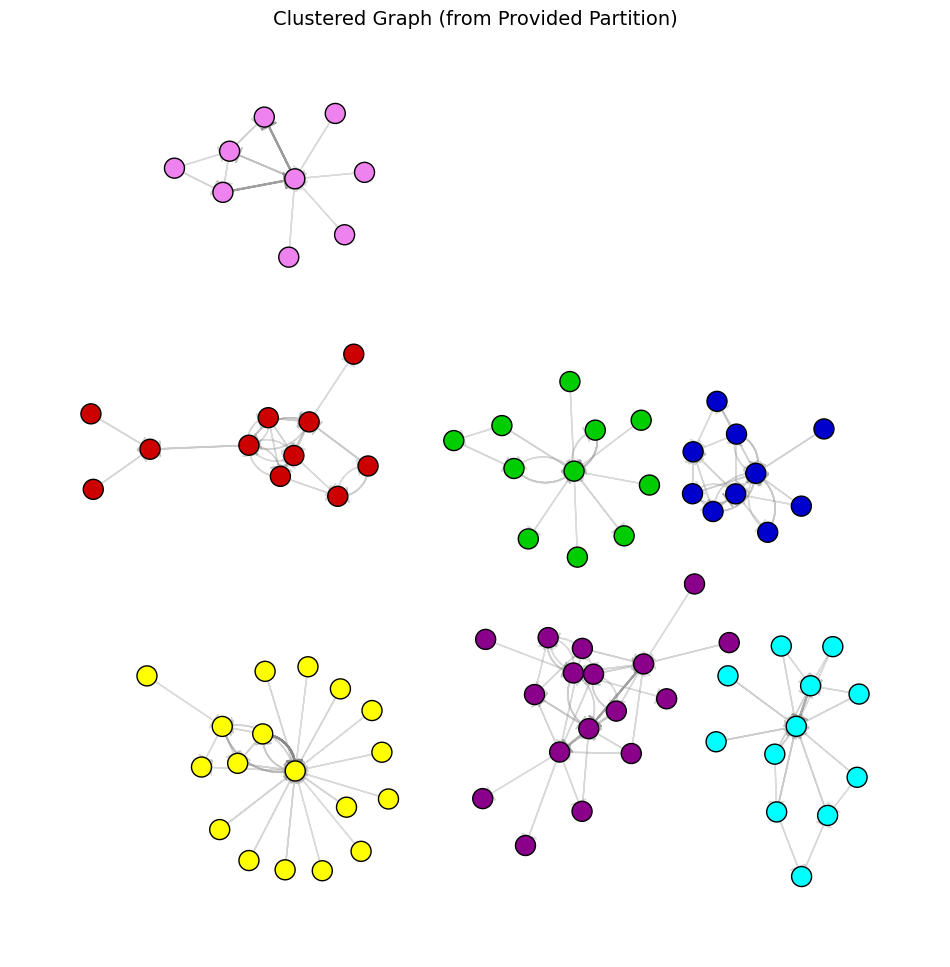

In [6]:
# Set seed for layout reproducibility
random.seed(seed)
np.random.seed(seed)

# Map tf → cluster
name_to_cluster = dict(zip(nodes_df["tf"], nodes_df["community"]))

# Assign cluster info to igraph nodes
ig_graph.vs["name"]  # assume this contains the tf names
ig_graph.vs["cluster"] = [name_to_cluster[name] for name in ig_graph.vs["name"]]

# Build subgraphs by cluster 
clusters = []
cluster_ids = sorted(set(name_to_cluster.values()))
for cluster_id in cluster_ids:
    node_indices = [v.index for v in ig_graph.vs if v["cluster"] == cluster_id]
    clusters.append(ig_graph.subgraph(node_indices))

# -- Step 2: Layouts and bounding boxes --
layouts = []
bboxes = []

for g_sub in clusters:
    layout = g_sub.layout("fr")  # reproducible via global random seed
    layout_np = np.array(layout) * 2.0
    layouts.append(layout_np)

    min_x, min_y = layout_np.min(axis=0)
    max_x, max_y = layout_np.max(axis=0)
    width = max_x - min_x
    height = max_y - min_y
    bboxes.append((width, height))

# -- Step 3: Grid layout placement --
num_clusters = len(clusters)
grid_cols = int(np.ceil(np.sqrt(num_clusters)))
padding = 5

global_layout = [None] * ig_graph.vcount()
cell_idx = 0

for cluster_id, (subgraph, layout_np, (w, h)) in zip(cluster_ids, zip(clusters, layouts, bboxes)):
    row = cell_idx // grid_cols
    col = cell_idx % grid_cols
    cell_idx += 1

    x_offset = col * (w + padding)
    y_offset = row * (h + padding)

    for i, (x, y) in enumerate(layout_np):
        node_name = subgraph.vs[i]["name"]
        global_index = ig_graph.vs.find(name=node_name).index
        global_layout[global_index] = (x + x_offset, y + y_offset)

# -- Step 4: Node color by cluster --

# Assign each cluster its color
cluster_id_to_color = {cid: custom_colors[i] for i, cid in enumerate(cluster_ids)}

# Apply to each vertex
ig_graph.vs["color"] = [cluster_id_to_color[name_to_cluster[name]] for name in ig_graph.vs["name"]]

# -- Step 5: Edge opacity by weight --
weights = np.array(ig_graph.es["weight"])
w_min, w_max = weights.min(), weights.max()
weights_norm = (weights - w_min) / (w_max - w_min + 1e-9)
weights_alpha = 0.3 + 0.7 * weights_norm

def rgba_gray_with_alpha(alpha):
    alpha_int = int(alpha * 255)
    return f"#888888{alpha_int:02X}"

ig_graph.es["color"] = [rgba_gray_with_alpha(a) for a in weights_alpha]

# -- Step 6: Plot --
fig, ax = plt.subplots(figsize=(12, 12))
ig.plot(
    ig_graph,
    layout=global_layout,
    target=ax,
    vertex_size=20,
    vertex_label=None,
    vertex_frame_color=None,
    vertex_shape="circle",
    edge_arrow_size=0.4,
    edge_width=[1 + 3 * w for w in weights],
    bbox=(800, 800),
    margin=40
)
plt.title("Clustered Graph (from Provided Partition)", fontsize=14)

# -- Step 7: Edge opacity legend --
legend_patches = [
    mpatches.FancyArrow(0, 0, 0.5, 0, width=0.01, color=rgba_gray_with_alpha(alpha), label=label)
    for alpha, label in zip([0.1, 0.5, 0.9], ["Low weight", "Medium", "High"])
]
# plt.legend(
#    handles=legend_patches,
#    loc="lower right",
#    title="Edge Weight (Opacity)",
#    frameon=False
#)

# -- Step 8: Save --
plt.savefig(os.path.join(res_folder, "clustered_graph.png"), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(res_folder, "clustered_graph.svg"), format='svg', bbox_inches='tight')
plt.show()

In [7]:
# Part 1: Find inter-community connections
inter_cluster_edges = set()

for edge in ig_graph.es:
    source_idx = edge.source
    target_idx = edge.target
    c1 = ig_graph.vs[source_idx]["cluster"]
    c2 = ig_graph.vs[target_idx]["cluster"]
    
    if c1 != c2:
        inter_cluster_edges.add(tuple(sorted((c1, c2))))

# Summary
print(f"{len(inter_cluster_edges)} community pairs have at least one edge between them.")
for pair in sorted(inter_cluster_edges):
    print(f"Community {pair[0]} ↔ Community {pair[1]}")

0 community pairs have at least one edge between them.


In [8]:
# Part 2: Nodes isolated from their own cluster
isolated_nodes = []

for v in ig_graph.vs:
    cluster = v["cluster"]
    neighbors = ig_graph.neighbors(v.index, mode="all")
    
    if not any(ig_graph.vs[n]["cluster"] == cluster for n in neighbors):
        isolated_nodes.append(v["name"])

# Summary
print(f"{len(isolated_nodes)} node(s) are not connected to any other node in their own community.")
if isolated_nodes:
    print("These nodes are:")
    for node in isolated_nodes:
        print(f" - {node}")

0 node(s) are not connected to any other node in their own community.
